# Build GNNs with Pytorch 
Using the esol_modified.csv data set to predict logP from structure

In [3]:
import math
import numpy
import pandas as pd
from pathlib import Path
import os
from rdkit import Chem

import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data

First, load the esol data set from session11

In [4]:
df = pd.read_csv(os.path.join("..", "..", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
# we will have trouble if the SMILES contains only a single atom (no graph can be constructed)
df = df.loc[df.SMILES != 'C']


In [5]:
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


Next, we encode the SMILES in the dataset into graph objects using RDKit

In [6]:
def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

In [7]:
def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

Obtain Graph representation of the data

In [8]:
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [40]:
class GCNModel(torch.nn.Module):
    def __init__(self, dim_h=64): # dim_h: Size of hidden layer
        super().__init__()
        self.conv1 = GCNConv(5, dim_h) # first convolution layer: in_channels: 5, number of atom features
        self.conv2 = GCNConv(dim_h, dim_h) # second convolution layer
        self.lin = torch.nn.Linear(dim_h, 1) # output layer
        
    # Define how the data flows through the layers
    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))  # input layer: convolution + activation function (ReLu)
        x = torch.relu(self.conv2(x, edge_index))  # hidden layer: convolution + activation function (ReLu)
        x = global_mean_pool(x, batch)             # pooling function
        return self.lin(x).squeeze(-1)


In [41]:
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # try: global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [42]:
class GATModel(torch.nn.Module):
    def __init__(self, dim_h=64, heads=4):
        super().__init__()

        # Input layer
        self.conv1 = GATConv(
            in_channels=5,        # your atom feature size
            out_channels=dim_h,  # hidden dimension per head
            heads=heads,
            dropout=0.1,
            concat=True           # concatenates heads --> output = hidden * heads
        )

        # Second layer
        self.conv2 = GATConv(
            in_channels=dim_h * heads,
            out_channels=dim_h,
            heads=1,
            dropout=0.1,
            concat=False          # final output shape = (hidden,)
        )

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)


In [52]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
              f"Val Loss = {val_loss:.4f}") 


def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")


In [44]:
def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)


In [45]:
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

Now, we load the data and train the GNNs

In [46]:
loader = DataLoader(graphs, batch_size=100, shuffle=True)

### change here the epochs for better result for training epochs and model, see plot down

In [ ]:
# training GCN for 10 epochs
gcn = GCNModel()
gin = GINModel()
gat = GATModel()

epochs = 100 

print("\n=== Training GCN ===")
train(gcn, train_loader, val_loader, epochs=epochs)
test(gcn, test_loader)

print("\n=== Training GIN ===")
train(gin, train_loader, val_loader, epochs=epochs)
test(gin, test_loader)

print("\n=== Training GAT ===")
train(gat, train_loader, val_loader, epochs=epochs)
test(gat, test_loader)


=== Training GCN ===
Epoch 01 | Train Loss = 4.7194 | Val Loss = 4.9611
Epoch 02 | Train Loss = 3.6093 | Val Loss = 5.1119
Epoch 03 | Train Loss = 3.4240 | Val Loss = 4.9985
Epoch 04 | Train Loss = 3.4127 | Val Loss = 5.1984
Epoch 05 | Train Loss = 3.3443 | Val Loss = 5.0085
Epoch 06 | Train Loss = 3.2433 | Val Loss = 5.0221
Epoch 07 | Train Loss = 3.1597 | Val Loss = 4.8682
Epoch 08 | Train Loss = 3.1987 | Val Loss = 4.9171
Epoch 09 | Train Loss = 3.1082 | Val Loss = 4.9388
Epoch 10 | Train Loss = 3.0978 | Val Loss = 4.7332
Epoch 11 | Train Loss = 3.0316 | Val Loss = 4.6499
Epoch 12 | Train Loss = 3.0236 | Val Loss = 4.5877
Epoch 13 | Train Loss = 3.0578 | Val Loss = 4.7842
Epoch 14 | Train Loss = 3.1821 | Val Loss = 4.6481
Epoch 15 | Train Loss = 3.0282 | Val Loss = 4.4713
Epoch 16 | Train Loss = 2.9701 | Val Loss = 4.4512
Epoch 17 | Train Loss = 2.8794 | Val Loss = 4.4320
Epoch 18 | Train Loss = 2.8956 | Val Loss = 4.3544
Epoch 19 | Train Loss = 2.9537 | Val Loss = 4.4247
Epoch 20 

In [63]:
import matplotlib.pyplot as plt
def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Usage:

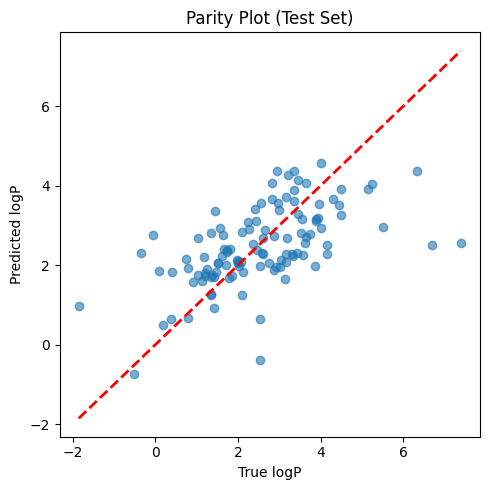

In [64]:
parity_plot(gcn, test_loader)

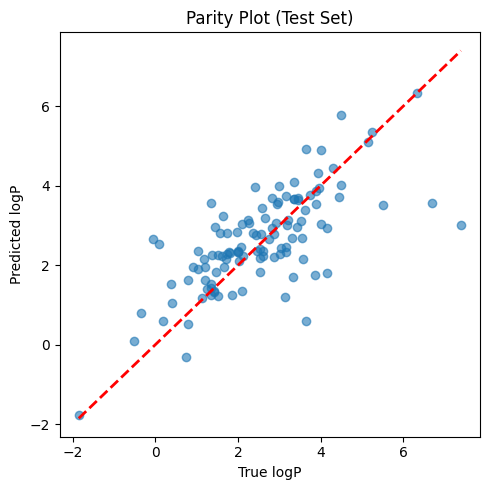

In [65]:
parity_plot(gin, test_loader)

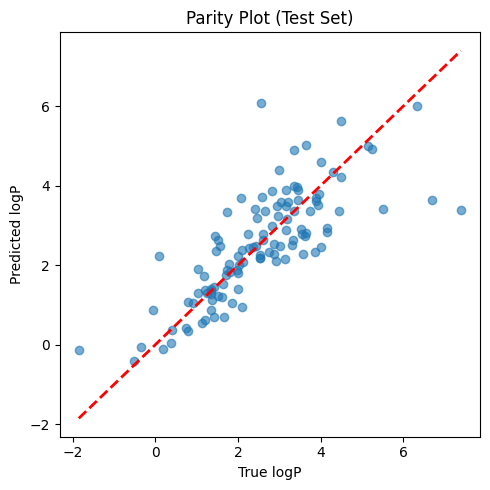

In [66]:
parity_plot(gat, test_loader)